In [63]:
import pandas as pd
import os
from scipy import stats  
import matplotlib.pyplot as plt
import numpy as np

# Get diagnoses

In [64]:
data_files : list = os.listdir('data')
diagnoses : list[str] = list(filter(lambda file: '.' not in file, data_files))

# Read all demographics data

In [65]:
demographics_list : list[pd.DataFrame] = []

for diagnosis in diagnoses:
    current_df : pd.DataFrame = pd.read_csv(
            f'data/{diagnosis}/demographics.tsv',
            sep = '\t',
            skiprows=1,
            header=0
        ).dropna(
            subset=['male']
        )
    
    current_df['diagnosis'] = diagnosis
    demographics_list.append(
        current_df
    )

full_demographics : pd.DataFrame = pd.concat(demographics_list).rename({
    'Unnamed: 0':'user_id'
}, axis=1)

In [66]:
full_demographics

,user_id,male,female,19-29,30-39,<=18,>=40,botscore,time_indication,diag_start_interval,diag_end_interval,diagnosis,non-org,is-org
1,uANX000,0.9979,0.0021,0.0041,0.0024,0.0010,0.9924,0.08,NaN,NaN,NaN,anxiety,NaN,NaN
2,uANX001,0.0007,0.9993,0.4307,0.5255,0.0120,0.0318,0.08,NaN,NaN,NaN,anxiety,NaN,NaN
3,uANX002,0.0267,0.9733,0.5156,0.2566,0.0631,0.1647,0.06,NaN,NaN,NaN,anxiety,NaN,NaN
4,uANX003,0.9946,0.0054,0.0087,0.9801,0.0005,0.0107,0.02,In 2013,2013-01-01 00:00:00,2013-12-31,anxiety,NaN,NaN
5,uANX004,0.0569,0.9431,0.6154,0.1212,0.1755,0.0879,0.00,Last year,2018-01-01 00:00:00,2018-12-31,anxiety,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1432,uDEP1431,0.0899,0.9101,0.2674,0.0114,0.7154,0.0058,0.30,NaN,NaN,NaN,depression,NaN,NaN
1433,uDEP1432,0.0042,0.9958,0.0326,0.9398,0.0038,0.0239,0.23,NaN,NaN,NaN,depression,NaN,NaN
1434,uDEP1433,0.1615,0.8385,0.1886,0.0006,0.8108,0.0001,0.30,NaN,NaN,NaN,depression,NaN,NaN
1,uPDD000,0.2270,0.7730,0.4701,0.0454,0.4479,0.0366,0.01,NaN,NaN,NaN,PDD,0.9040,0.0960


# Read all tweets data

In [67]:
tweets_list : list[pd.DataFrame] = []

for diagnosis in diagnoses:
    tweets_list.append(
        pd.read_csv(
            f'data/{diagnosis}/tweets.tsv',
            sep = '\t',
            header=0,
            index_col=0
        )
    )

full_tweets : pd.DataFrame = pd.concat(tweets_list).reset_index()

# Reformat comorbidities
Comorbidities table must be transformed, such that it contains nicer user IDs

In [68]:
comorbidities_raw : pd.DataFrame = pd.read_csv(f'data/comorbidities.txt')

def split_mapping(expr : str) -> dict[str, str]:
    parts : list[str] = expr.split(' = ')
    return {
        parts[0] : parts[1]
    }

id_mapping_list : list[dict[str, str]] = comorbidities_raw.apply(lambda row: split_mapping(row.iloc[0]), axis=1).to_list()
id_mapping : dict[str, str] = {}

for map in id_mapping_list:
    id_mapping.update(map)


# Update user IDs in tweets and demographics

## Demographics

In [69]:
full_demographics['user_id'] = full_demographics['user_id'].map(lambda x: id_mapping.get(x, x))
full_demographics = full_demographics.drop_duplicates(subset=['user_id'])

## Tweets

In [70]:
full_tweets['user_id'] = full_tweets['user_id'].map(lambda x: id_mapping.get(x, x))
full_tweets = full_tweets.drop_duplicates()

# Get cohort mapping

In [71]:
cohorts_raw : pd.DataFrame = pd.read_csv('data/cohort_mapping.tsv', sep = '\t')
cohorts_raw['user_id'] = cohorts_raw['comorbidities'].map(lambda x: id_mapping.get(x.split(' = ')[0],x))
cohorts : pd.DataFrame = cohorts_raw.drop('comorbidities', axis=1).drop_duplicates()

# Join tables

In [72]:
tweets_demographics : pd.DataFrame = pd.merge(
    full_tweets,
    full_demographics,
    'left',
    on = 'user_id'
)

In [73]:
data : pd.DataFrame = pd.merge(
    tweets_demographics,
    cohorts,
    'left',
    on = 'user_id'
)

# Get cohort

In [74]:
data['cohort'] = data.apply(
    lambda row: 'depression' if row['group_depression'] else 'anxiety' if row['group_anxiety'] else 'other',
    axis=1
)

In [75]:
data

,tweet_id,user_id,created_at,ANEW_Valence,ANEW_Dominance,ANEW_Arousal,Happiness,NRC_anger,NRC_anticipation,NRC_disgust,...,time_indication,diag_start_interval,diag_end_interval,diagnosis,non-org,is-org,group_depression,group_anxiety,comorbid,cohort
0,tD2616022,uANX100,2020-07-07 00:19:36+00:00,5.640000,5.958333,3.738333,5.315789,0.0,0.0,0.0,...,NaN,NaN,NaN,anxiety,NaN,NaN,False,False,True,other
1,tD2616023,uANX100,2020-07-06 05:23:16+00:00,5.739333,5.518667,4.170000,5.692326,0.0,0.0,0.0,...,NaN,NaN,NaN,anxiety,NaN,NaN,False,False,True,other
2,tD2616024,uANX100,2020-07-05 06:31:37+00:00,5.993125,5.700000,3.906875,5.299487,0.0,3.0,0.0,...,NaN,NaN,NaN,anxiety,NaN,NaN,False,False,True,other
3,tD2616025,uANX100,2020-07-05 06:23:43+00:00,4.873333,4.896667,4.016667,5.250000,0.0,0.0,0.0,...,NaN,NaN,NaN,anxiety,NaN,NaN,False,False,True,other
4,tD2616026,uANX100,2020-07-04 11:38:28+00:00,6.292632,5.936316,3.678947,5.612857,0.0,0.0,0.0,...,NaN,NaN,NaN,anxiety,NaN,NaN,False,False,True,other
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4079750,tD0139188,uPDD001,2019-07-27 17:19:28+00:00,6.500000,6.310000,3.140000,5.493333,0.0,0.0,0.0,...,NaN,NaN,NaN,dysthymia,0.9998,0.0002,False,False,True,other
4079751,tD0139189,uPDD001,2019-07-27 17:19:05+00:00,NaN,NaN,NaN,NaN,0.0,0.0,0.0,...,NaN,NaN,NaN,dysthymia,0.9998,0.0002,False,False,True,other
4079752,tD0139190,uPDD001,2019-07-27 17:16:25+00:00,5.780000,4.670000,3.710000,5.252000,0.0,0.0,0.0,...,NaN,NaN,NaN,dysthymia,0.9998,0.0002,False,False,True,other
4079753,tD0139191,uPDD001,2019-07-27 17:16:15+00:00,NaN,NaN,NaN,6.090000,0.0,0.0,0.0,...,NaN,NaN,NaN,dysthymia,0.9998,0.0002,False,False,True,other


# Enrich data

In [76]:
data = data.loc[data.created_at < "2020-05-01"]

# Fix timezones

## Get timezone info

In [77]:
timezones = pd.read_csv('cohort_timezones.tsv', sep='\t')
timezones = timezones.dropna().rename({'tz':'timezone'}, axis=1)
timezones

data_tz = pd.merge(data, timezones, 'left', on='user_id')
data_tz.dropna(subset=['timezone'], inplace=True)
print(data.shape, data_tz.shape)
data_tz.timezone.unique()
print(data_tz.user_id.nunique(), data.user_id.nunique())

(2679519, 37) (630801, 38)
419 2102


## Adjust reference times

In [78]:
from datetime import datetime, timezone
import pytz
from dateutil import parser  # Robust datetime string parsing

def adjust_datetime_to_timezone(dt=None, tz_str='UTC'):
    # Step 1: Parse string input if needed
    if isinstance(dt, str):
        dt = parser.parse(dt)  # Automatically handles tz-aware strings too

    # Step 2: Default to current UTC time if dt is None
    if dt is None:
        return None

    # Step 3: Ensure datetime is tz-aware; assume UTC if naive
    if dt.tzinfo is None:
        dt = dt.replace(tzinfo=timezone.utc)

    # Step 4: Convert to target timezone
    target_tz = pytz.timezone(tz_str)
    adjusted_dt = dt.astimezone(target_tz)
    return adjusted_dt

data_tz['created_at'] = data_tz.apply(
    lambda row: adjust_datetime_to_timezone(row['created_at'], row['timezone']),
    axis=1
)


## Function to infer time zone for users

In [79]:
from datetime import datetime, timedelta
from dateutil import parser
from collections import Counter

def get_hour_proportions(datetimes):
    rounded_hours = []
    for dt in datetimes:
        if isinstance(dt, str):
            dt = parser.parse(dt)

        if dt.minute >= 30:
            dt += timedelta(hours=1)
        rounded_hour = dt.hour
        rounded_hours.append(rounded_hour)

    total = len(rounded_hours)
    hour_counts = Counter(rounded_hours)
    proportions = {hour: count / total for hour, count in hour_counts.items()}
    return proportions

def mean_absolute_error(dist1, dist2):
    # Ensure all 24 hours are represented
    all_hours = set(range(24))
    for hour in all_hours:
        dist1.setdefault(hour, 0)
        dist2.setdefault(hour, 0)
    error = sum(abs(dist1[h] - dist2[h]) for h in all_hours) / 24
    return error

def adjust_to_match_reference(datetimes, reference_proportions):
    best_offset = 0
    min_error = float('inf')
    best_shifted_datetimes = []

    for offset in range(-12, 15):  # UTC offsets from -12 to +14
        shifted = []
        for dt in datetimes:
            if isinstance(dt, str):
                dt = parser.parse(dt)
            shifted_dt = dt + timedelta(hours=offset)
            shifted.append(shifted_dt)

        shifted_proportions = get_hour_proportions(shifted)
        error = mean_absolute_error(shifted_proportions, reference_proportions)

        if error < min_error:
            min_error = error
            best_offset = offset
            best_shifted_datetimes = shifted

    return best_shifted_datetimes, best_offset

# Example usage
reference_hours = get_hour_proportions(data_tz['created_at'])


In [80]:
from datetime import datetime, timedelta
from dateutil import parser
import numpy as np

def adjust_to_match_reference(datetimes, reference_proportions):
    # Step 1: Parse datetimes once and compute float hour values
    dt_list = []
    hour_floats = []

    for dt in datetimes:
        if isinstance(dt, str):
            dt = parser.parse(dt)
        dt_list.append(dt)
        hour_float = dt.hour + dt.minute / 60
        hour_floats.append(hour_float)

    hour_floats = np.array(hour_floats)
    n = len(hour_floats)

    # Step 2: Build reference array of proportions for hours 0–23
    ref_array = np.zeros(24)
    for hour, prop in reference_proportions.items():
        ref_array[hour % 24] = prop

    # Step 3: Preallocate array for MAEs per offset
    offsets = np.arange(-12, 15)
    mae_errors = np.zeros_like(offsets, dtype=float)

    # Step 4: Efficiently process each offset
    for i, offset in enumerate(offsets):
        shifted_hours = (hour_floats + offset) % 24
        rounded_hours = np.round(shifted_hours).astype(int) % 24

        # Fast histogram (bincount) for proportions
        counts = np.bincount(rounded_hours, minlength=24)
        proportions = counts / n

        # Vectorized MAE calculation
        mae_errors[i] = np.mean(np.abs(proportions - ref_array))

    # Step 5: Get best offset (smallest MAE)
    best_idx = np.argmin(mae_errors)
    best_offset = offsets[best_idx]

    # Step 6: Shift original datetime objects once
    adjusted_dts = [dt + timedelta(hours=int(best_offset)) for dt in dt_list]

    return adjusted_dts, int(best_offset)

In [81]:
from datetime import datetime, timedelta
from dateutil import parser
import numpy as np
from numba import njit

@njit
def find_best_offset_numba(hour_floats, ref_array, offsets):
    n = hour_floats.size
    min_mae = 1e9
    best_offset = 0

    for offset in offsets:
        shifted_hours = (hour_floats + offset) % 24
        rounded_hours = np.round(shifted_hours) % 24
        rounded_hours = rounded_hours.astype(np.int32)

        counts = np.zeros(24, dtype=np.int32)
        for i in range(n):
            counts[rounded_hours[i]] += 1

        proportions = counts / n
        mae = 0.0
        for h in range(24):
            mae += abs(proportions[h] - ref_array[h])
        mae /= 24

        if mae < min_mae:
            min_mae = mae
            best_offset = offset

    return best_offset, min_mae

def adjust_to_match_reference(datetimes, reference_proportions):
    # Parse and extract float hours
    dt_list = []
    hour_floats = []

    for dt in datetimes:
        if isinstance(dt, str):
            dt = parser.parse(dt)
        dt_list.append(dt)
        hour_float = dt.hour + dt.minute / 60
        hour_floats.append(hour_float)

    hour_floats_np = np.array(hour_floats, dtype=np.float32)

    # Reference array for 24 hours
    ref_array = np.zeros(24, dtype=np.float32)
    for hour, prop in reference_proportions.items():
        ref_array[hour % 24] = prop

    offsets = np.arange(-12, 15, dtype=np.int32)

    # Numba-accelerated offset finder
    best_offset, best_error = find_best_offset_numba(hour_floats_np, ref_array, offsets)

    # Shift datetimes by best offset
    adjusted_datetimes = [dt + timedelta(hours=int(best_offset)) for dt in dt_list]

    return adjusted_datetimes, int(best_offset), best_error


In [82]:
data['inferred_timezone'] = None

for user, subdf in data.groupby('user_id'):
    adjusted_dts, offset, loss = adjust_to_match_reference(subdf['created_at'], reference_hours)
    data.loc[data['user_id'] == user, 'created_at'] = adjusted_dts
    data.loc[data['user_id'] == user, 'inferred_timezone'] = offset
    data.loc[data['user_id'] == user, 'timezone_loss'] = loss
    print(user)
    

/var/folders/7d/2d_kq54s00v0272gkndgzxd80000gn/T/ipykernel_7736/1010240267.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['inferred_timezone'] = None
/var/folders/7d/2d_kq54s00v0272gkndgzxd80000gn/T/ipykernel_7736/1010240267.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.loc[data['user_id'] == user, 'timezone_loss'] = loss


uANX000
uANX001
uANX003
uANX004
uANX005
uANX006
uANX007
uANX008
uANX009
uANX010
uANX011
uANX012
uANX013
uANX014
uANX015
uANX016
uANX017
uANX018
uANX019
uANX020
uANX021
uANX022
uANX023
uANX024
uANX025
uANX026
uANX027
uANX028
uANX029
uANX031
uANX032
uANX033
uANX034
uANX037
uANX038
uANX039
uANX041
uANX042
uANX043
uANX044
uANX045
uANX047
uANX048
uANX049
uANX050
uANX051
uANX052
uANX053
uANX054
uANX055
uANX056
uANX057
uANX058
uANX059
uANX060
uANX061
uANX062
uANX063
uANX064
uANX065
uANX066
uANX067
uANX068
uANX070
uANX071
uANX072
uANX073
uANX074
uANX075
uANX076
uANX077
uANX078
uANX079
uANX080
uANX081
uANX082
uANX083
uANX084
uANX085
uANX086
uANX088
uANX090
uANX091
uANX092
uANX093
uANX095
uANX097
uANX098
uANX099
uANX100
uANX1000
uANX1001
uANX1002
uANX1003
uANX1005
uANX1006
uANX1008
uANX1009
uANX1011
uANX1012
uANX1013
uANX1014
uANX1015
uANX1016
uANX1019
uANX102
uANX1020
uANX1021
uANX1022
uANX1023
uANX1025
uANX1026
uANX1027
uANX1028
uANX1030
uANX1031
uANX1032
uANX1033
uANX1034
uANX1035
uANX1036
uA

KeyboardInterrupt: 

In [ ]:
data.inferred_timezone

215        -7
216        -7
217        -7
218        -7
219        -7
           ..
4079750    -8
4079751    -8
4079752    -8
4079753    -8
4079754    -8
Name: inferred_timezone, Length: 2679519, dtype: object

## Day of week

In [ ]:

def get_day_of_week(ts):
    return pd.Timestamp(ts).dayofweek

data['day_of_week'] = data['created_at'].map(get_day_of_week)

/var/folders/7d/2d_kq54s00v0272gkndgzxd80000gn/T/ipykernel_7736/1260023609.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['day_of_week'] = data['created_at'].map(get_day_of_week)


## Gender (female propensity)

In [ ]:
data['female_prop'] = data['female'] - data['male']
data['gender'] = data['female'].map(lambda x: 'female' if x > 0.8 else 'male' if x < 0.2 else None)

/var/folders/7d/2d_kq54s00v0272gkndgzxd80000gn/T/ipykernel_7736/464910195.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['female_prop'] = data['female'] - data['male']
/var/folders/7d/2d_kq54s00v0272gkndgzxd80000gn/T/ipykernel_7736/464910195.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['gender'] = data['female'].map(lambda x: 'female' if x > 0.8 else 'male' if x < 0.2 else None)


In [ ]:
correction_df_dow_gender : pd.DataFrame = data.groupby(['gender', 'day_of_week'])[['VADER']].mean().reset_index().rename({'VADER' : 'VADER_correction'}, axis = 1)

[0, 1, 2, 3, 4, 5, 6]
[304143 310783 317580 313263 295967 273528 288874]


/var/folders/7d/2d_kq54s00v0272gkndgzxd80000gn/T/ipykernel_7736/3762097707.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


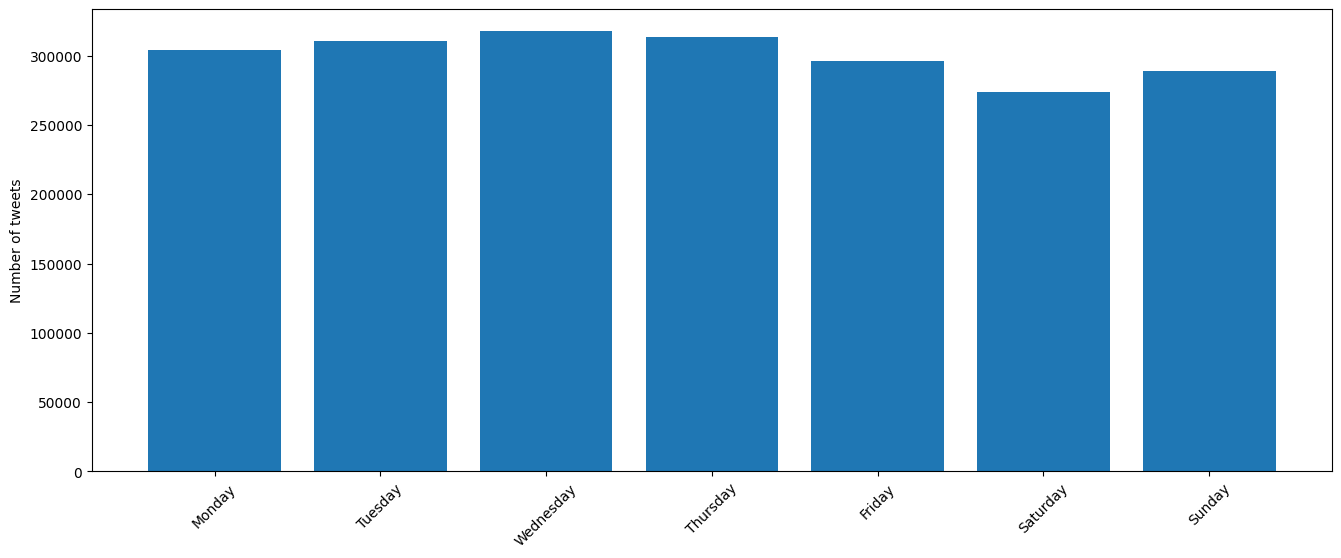

In [ ]:
dow_prob = data.groupby('day_of_week')[['tweet_id']].count().iloc[:,0]#.plot(kind="bar")
print(dow_prob.index.to_list())
print(dow_prob.values)
fig, ax = plt.subplots(figsize=(16,6))
plt.bar(
    dow_prob.index.to_list(),
    dow_prob.values
)

ax.set_xticklabels(
    [
        '',
        'Monday',
        'Tuesday',
        'Wednesday',
        'Thursday',
        'Friday',
        'Saturday',
        'Sunday'
    ],
    rotation = 45
)

ax.set_ylabel('Number of tweets')

plt.savefig('figures/tweets_by_dow.png', dpi=400, bbox_inches='tight')

plt.show()



In [ ]:
hours = data['created_at'].map(lambda x: (pd.Timestamp(x).hour * 60 + pd.Timestamp(x).minute) / 60)

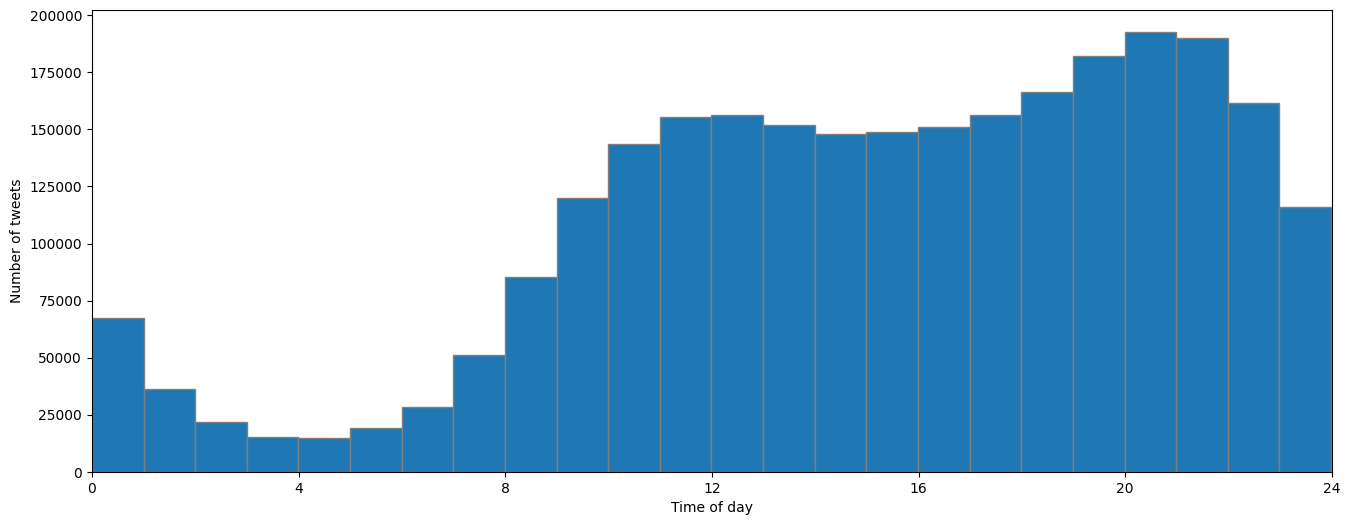

In [ ]:

fig, ax = plt.subplots(figsize=(16,6))

ax.hist(hours, bins = 24,edgecolor='grey')

ax.set_xticks(
    [
        0,
        4,
        8,
        12,
        16,
        20,
        24
    ]
)

ax.set_xlim(0,24)

ax.set_xlabel('Time of day')
ax.set_ylabel('Number of tweets')

plt.savefig('figures/tweets_per_hour.png', dpi=400, bbox_inches='tight')

In [ ]:
data.drop_duplicates(subset=['user_id']).shape, data.shape

((2102, 42), (2679519, 42))

In [ ]:
vader_scores_raw = pd.read_csv('project_data/VADER_scores 2.tsv', sep = '\t')

In [ ]:
vader_scores_raw.tweet_id = vader_scores_raw.tweet_id.map(lambda x: x.replace('t', 'tD'))

In [ ]:
vader_scores_raw.columns

Index(['tweet_id', 'user_id', 'created_at', 'VADER', 'VADER_NEG', 'VADER_NEU',
       'VADER_POS'],
      dtype='object')

In [ ]:
data = pd.merge(
    data,
    vader_scores_raw.drop(['user_id', 'created_at', 'VADER'], axis=1),
    how='inner',
    on=['tweet_id']
)

In [ ]:
data

,tweet_id,user_id,created_at,ANEW_Valence,ANEW_Dominance,ANEW_Arousal,Happiness,NRC_anger,NRC_anticipation,NRC_disgust,...,comorbid,cohort,inferred_timezone,timezone_loss,day_of_week,female_prop,gender,VADER_NEG,VADER_NEU,VADER_POS
0,tD2616237,uANX100,2020-04-30 14:43:57+00:00,3.352500,5.570000,4.537500,4.501818,0.0,0.0,2.0,...,True,other,-7,0.007052,3,0.954,female,0.000,0.761,0.239
1,tD2616238,uANX100,2020-04-29 19:58:40+00:00,3.220000,2.560000,5.450000,4.260000,0.0,0.0,0.0,...,True,other,-7,0.007052,2,0.954,female,0.304,0.617,0.079
2,tD2616239,uANX100,2020-04-29 19:56:33+00:00,5.681667,5.098333,3.965000,5.322105,0.0,1.0,0.0,...,True,other,-7,0.007052,2,0.954,female,0.000,1.000,0.000
3,tD2616240,uANX100,2020-04-29 00:46:02+00:00,3.850000,5.170000,4.670000,5.380000,0.0,0.0,0.0,...,True,other,-7,0.007052,2,0.954,female,0.000,1.000,0.000
4,tD2616241,uANX100,2020-04-28 05:48:45+00:00,6.100000,5.930000,4.246667,5.514091,0.0,0.0,0.0,...,True,other,-7,0.007052,1,0.954,female,0.000,0.860,0.140
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2104133,tD0139188,uPDD001,2019-07-27 09:19:28+00:00,6.500000,6.310000,3.140000,5.493333,0.0,0.0,0.0,...,True,other,-8,0.021424,5,0.744,female,0.086,0.795,0.119
2104134,tD0139189,uPDD001,2019-07-27 09:19:05+00:00,NaN,NaN,NaN,NaN,0.0,0.0,0.0,...,True,other,-8,0.021424,5,0.744,female,0.000,0.714,0.286
2104135,tD0139190,uPDD001,2019-07-27 09:16:25+00:00,5.780000,4.670000,3.710000,5.252000,0.0,0.0,0.0,...,True,other,-8,0.021424,5,0.744,female,0.000,0.572,0.428
2104136,tD0139191,uPDD001,2019-07-27 09:16:15+00:00,NaN,NaN,NaN,6.090000,0.0,0.0,0.0,...,True,other,-8,0.021424,5,0.744,female,0.000,0.747,0.253


In [ ]:
data.to_csv('project_data/full_dataset.csv',index=False)

# 6-hour windowed data

In [53]:
def get_windows(subdf):
    subdf.index = pd.to_datetime(subdf['created_at'])
    subdf = subdf.sort_index()
    subdf['gender_female'] = subdf['gender'].map(lambda x: 1 if x == 'female' else 0)
    #print(subdf.index)
    return subdf.rolling(
        window = '6h',
        min_periods = 2,
        center=True
    ).agg({
        'VADER_NEG': 'mean',
        'group_anxiety': 'min',
        'group_depression': 'min',
        'comorbid':'min',
        'gender_female' : 'min',
        '19-29' : 'mean',
        '30-39' : 'mean',
        '<=18' : 'mean',
        '>=40' : 'mean',
        'day_of_week' : 'median'
    }).dropna()

data_aggregated = data.groupby('user_id').apply(get_windows).reset_index()

data_aggregated

/var/folders/7d/2d_kq54s00v0272gkndgzxd80000gn/T/ipykernel_7736/2956861377.py:23: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data_aggregated = data.groupby('user_id').apply(get_windows).reset_index()


,user_id,created_at,VADER_NEG,group_anxiety,group_depression,comorbid,gender_female,19-29,30-39,<=18,>=40,day_of_week
0,uANX001,2020-03-24 18:43:59+00:00,0.158000,1.0,0.0,0.0,1.0,0.4307,0.5255,0.0120,0.0318,1.0
1,uANX001,2020-03-24 20:36:27+00:00,0.122417,1.0,0.0,0.0,1.0,0.4307,0.5255,0.0120,0.0318,1.0
2,uANX001,2020-03-24 21:20:58+00:00,0.134071,1.0,0.0,0.0,1.0,0.4307,0.5255,0.0120,0.0318,1.0
3,uANX001,2020-03-24 21:22:19+00:00,0.134071,1.0,0.0,0.0,1.0,0.4307,0.5255,0.0120,0.0318,1.0
4,uANX001,2020-03-24 21:22:50+00:00,0.134071,1.0,0.0,0.0,1.0,0.4307,0.5255,0.0120,0.0318,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
1840294,uSAD005,2020-04-30 07:42:28+00:00,0.092000,0.0,1.0,0.0,1.0,0.1901,0.7681,0.0062,0.0356,3.0
1840295,uSAD005,2020-04-30 07:42:59+00:00,0.092000,0.0,1.0,0.0,1.0,0.1901,0.7681,0.0062,0.0356,3.0
1840296,uSAD005,2020-04-30 07:46:32+00:00,0.092000,0.0,1.0,0.0,1.0,0.1901,0.7681,0.0062,0.0356,3.0
1840297,uSAD005,2020-04-30 16:16:10+00:00,0.121500,0.0,1.0,0.0,1.0,0.1901,0.7681,0.0062,0.0356,3.0


In [54]:
data_aggregated['gender'] = data_aggregated['gender_female'].map(lambda x: 'female' if x == 1 else 'male')

In [55]:
data_aggregated.to_csv('project_data/windowed_mean_data.csv')

# Daily data

In [62]:

data['day'] = data['created_at'].map(lambda x: str(x).split(' ')[0])
data['gender_female'] = data['gender'].map(lambda x: 1 if x == 'female' else 0)

data_aggregated = data.groupby(['user_id', 'day']).agg({
        'VADER_NEG': 'mean',
        'group_anxiety': 'min',
        'group_depression': 'min',
        'comorbid':'min',
        'gender_female' : 'min',
        '19-29' : 'mean',
        '30-39' : 'mean',
        '<=18' : 'mean',
        '>=40' : 'mean',
        'day_of_week' : 'median'
    }).dropna().reset_index()

data_aggregated['gender'] = data_aggregated['gender_female'].map(lambda x: 'female' if x == 1 else 'male')

data_aggregated.to_csv('project_data/daily_mean_data.csv')